In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt

spark = SparkSession.builder.master("local[*]").getOrCreate()
sc = spark.sparkContext

In [3]:
#데이터 생성
K=3
n=1000
X,y = make_blobs(n_samples=n, centers=K, n_features=2)

rdd = sc.parallelize(X)

In [5]:
#초기 중심점 랜덤 설정
centers = X[np.random.choice(X.shape[0], K, replace=False)]
max_iter=10

In [7]:
for i in range(max_iter):
  b_centers = sc.broadcast(centers)

  #step1 map단계. 각 데이터가 어떤 중심점과 가장 가까운지 찾기
  def closest_center(point, center):
    #유클리드 거리 계산. axis=1 -> 각 중심점마다 거리 계산
    distances = np.linalg.norm(point-center, axis=1)
    #가장 거리가 짧은 인덱스 0,1,2중 하나 반환
    return np.argmin(distances)

  assign_rdd = rdd.map(lambda p:(
                       closest_center(p, b_centers.value), (p, 1)))
  #결과 형태로 (클러스터 id, (좌표벡터p, 개수인 1))

  #step2 reduce단계
  #같은 클러스터끼리 좌표 다 더하고 개수까지 더함
  sum_rdd = assign_rdd.reduceByKey(lambda a, b: (a[0]+b[0], a[1]+b[1]))

  #step3 새로운 중심점 계산
  new_center = sum_rdd.mapValues(lambda v: v[0]/v[1]).collect()

  new_center.sort(key=lambda x:x[0])
  centers=np.array([info[1] for info in new_center])
  print(f"Iteration {i+1} Complete")

Iteration 1 Complete
Iteration 2 Complete
Iteration 3 Complete
Iteration 4 Complete
Iteration 5 Complete
Iteration 6 Complete
Iteration 7 Complete
Iteration 8 Complete
Iteration 9 Complete
Iteration 10 Complete


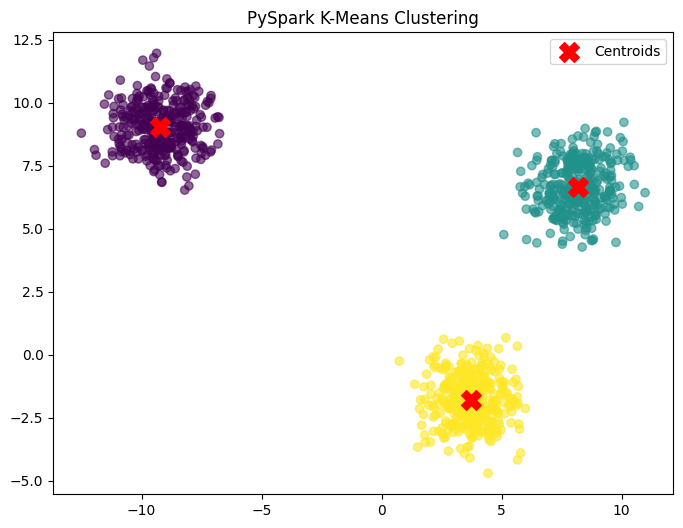

In [8]:
# --- 결과 시각화 ---
# 최종 예측 (색칠하기 위해)
final_pred = rdd.map(lambda p: closest_center(p, centers)).collect()

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=final_pred, alpha=0.6, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("PySpark K-Means Clustering")
plt.legend()
plt.show()